# Visión por Computador - Práctica 2 - Deep Learning en Computer Vision

#### 15 puntos   |   Fecha de entrega: 7 de Diciembre, 23:59   |   Forma de entrega: a través de la tarea creada en https://pradogrado2526.ugr.es/

### Estudiante: <mark>Jaime Corzo Galdó</mark>

## Normas de desarrollo y entrega de la práctica

1. Para este trabajo, al igual que para los demás, se debe presentar código, resultados, discusión de los mismos, y presentación y análisis del trabajo realizado, todo integrado en el propio Google Colab Notebook (es decir, no se entrega ninguna memoria separada en `.pdf` ni ningún código `.py`). Se recuerda que código y resultados sin informe explicativo no puntúa. Resulta también fundamental recordar que solo se acepta la entrega de ficheros `.ipynb` (no resulta válido entregar un fichero `.py`).

2. En relación con el punto anterior, se recuerda que se proporciona un Notebook, denominado `Ejemplo_Otsu.ipynb`, que muestra un ejemplo de respuesta y solución a un potencial ejercicio. El propósito de este Notebook es servir de referencia al alumnado acerca de cómo responder los ejercicios planteados. Véase que, por ejemplo, en aras de diferenciar con facilidad enunciados y respuestas, estas últimas se presentan en otro color (azul, en ese caso).

3. El diseño de celdas del documento debe ser respetado. Es decir, no se puede modificar el orden de los ejercicios o alterar la estructura del Notebook, de forma que dificulte localizar los contenidos. Aunque sí se puede, por ejemplo, crear nuevas subsecciones dentro de las secciones ya existentes para estructurar y organizar con más claridad las respuestas, así como para incluir los experimentos extra que se deseen.

4. Tal y como se muestra en `Ejemplo_Otsu.ipynb`, no hay ningún problema en emplear técnicas de IA generativa (como ChatGPT o Gemini) para crear el código de los distintos ejercicios o para enriquecer el análisis y descripción del trabajo realizado (aunque, obvia decirlo, su uso no es obligatorio). Pero, en caso de usarse, sí se debe aclarar de qué modo se ha usado la IA, con qué objetivo, y se debe demostrar que se entiende perfectamente lo que se ha hecho.

5. Solo se entregará el fichero `.ipynb` (incorporando código, resultados, y explicación del trabajo realizado y los resultados obtenidos) y no se enviarán las imágenes empleadas. El path para la lectura de imágenes, o cualquier otro fichero de entrada, debe ser siempre “/content/drive/My Drive/images/nombre_fichero”.

6. El código deberá  presentarse adecuadamente comentado y con los resultados obtenidos en cada apartado, junto con la presentación del trabajo realizado y la discusión y análisis de los resultados obtenidos. Es importante reiterar que la entrega de código sin informe explicativo o valoraciones no puntúa. Por otro lado, el código debe ir comentado en comentarios en celdas de código, mientras que el análisis y discusión, tanto del trabajo realizado como de los resultados obtenidos, debe ir en celdas de texto.






### Materiales de Apoyo

En caso de que el alumnado tenga dudas sobre Python, OpenCV o el uso de Google Colab, se recuerda que en PRADO hay materiales de apoyo (https://pradogrado2526.ugr.es/mod/folder/view.php?id=95307):
-  Introducción a Python: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/1.%20Introduccion%20a%20Python.pdf
- Introducción a NumPy, Matplotlib y Scikit-learn: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/2.%20Introducción%20a%20Numpy%20Matplotlib%20y%20sklearn.pdf
- Notebook con toda la información anterior (y más cosas): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_Python.ipynb
- Ejercicios y ejemplos de repaso: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/3.%20Ejercicios%20y%20ejemplos%20de%20repaso.pdf
- Fundamentos de Python para lectura, visualización y manipulación de imágenes: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/4.%20Fundamentos%20de%20Python%20para%20manipulacion%20de%20imagenes.pdf (y Notebook asociado: https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Guia_fundamentos_imagenes.ipynb)
- Ideas sobre cómo redactar un documento académico-científico (útil para saber cómo documentar las respuestas a los ejercicios, el Notebook en su conjunto, y la memoria del proyecto final o de un TFG/TFM): https://pradogrado2526.ugr.es/pluginfile.php/243163/mod_folder/content/0/Algunas%20ideas%20sobre%20cómo%20elaborar%20un%20informe%20académico-científico.pdf
- Ejemplo de respuesta a un hipotético ejercicio sobre el algoritmo de umbralización de Otsu: https://pradogrado2526.ugr.es/pluginfile.php/243164/mod_folder/content/0/Ejemplo_Otsu.ipynb

# <font color='blue'>**Ejercicio  3: Transfer Learning y fine-tuning con ResNet34 en el SPR X-Ray Age Prediction Challenge (4 points)**
<font color='blue'>En este ejercicio trabajaremos con el _SPR X-Ray Age Prediction Challenge_ de Kaggle (https://www.kaggle.com/competitions/spr-x-ray-age/data). Este dataset consta de $10 702$ radiografías de tórax, y el objetivo es predecir la edad de la persona a partir de la imagen de la radiografía. En esta ocasión, se emplearán $6 702$ imágenes para entrenamiento y $4 000$ para test. Las edades oscilan entre los 18 y los 89 años. Para facilitar el trabajo al alumnado se proporciona una versión procesada de los datos (con resolución $224\times224$, en lugar de $1024\times1024$, y empleando solo ejemplos para los cuales se tiene salida deseada (dado que, al tratarse de una challenge de kaggle, el conjunto de test está disponible pero sin etiquetar)). Estos datos se pueden acceder desde: https://drive.google.com/drive/folders/1hCWfTLs1w0h5kObl6NEIhEtH5VDmmCnj?usp=sharing (se debe emplear una cuenta de la UGR para acceder a dicha URL, y la información allí contenida (directorio `spr-x-ray-age`) se debe incluir en la carpeta `Colab Notebooks`).

<font color='blue'>Se debe emplear un $20\%$ de los datos de entrenamiento para validación, y el rendimiento debe ser evaluado, como mínimo, por medio de $MSE$, $MAE$ y $R^2$ _(coefficient of determination) score_. Se deben justificar las decisiones tomadas, como la elección de la función de pérdida. Del mismo modo, es necesario hacer un `summary()` de las arquitecturas empleadas en cada apartado, indicando qué parámetros/capas/bloques son entrenables y cuáles no lo son (es decir, en cada apartado es imprescindible destacar claramente qué arquitectura exacta se está utilizando, así como qué pesos se están entrenando y cuáles se están congelando).

<font color='blue'>Usaremos un modelo ResNet34 pre-entrenado en ImageNet, y tendremos que realizar los experimentos, y responder las preguntas, que se muestran a continuación:

  <font color='blue'>
  
  1. (0.75 puntos) Partimos de ResNet34, adaptamos la cabecera (sustituyendo la cabecera anterior por *una única fully-connected* con el número de neuronas de salida adecuado), y reentrenamos (_from scratch_) la red entera para este nuevo problema durante $15$ épocas. Es decir, partimos de pesos aleatorios para resolver este problema de regresión.

  <font color='blue'>

  2. <font color='blue'> (1.25 puntos) Partimos de ResNet34, adaptamos la cabecera (empleando la misma del apartado anterior), y entrenamos solo la cabecera incorporada. Es decir, ResNet34 se usa como un mero extractor de características (preentrenado en ImageNet), y los pesos que se entrenan  durante $15$ épocas son los de la nueva capa incorporada (manteniendo fijos/congelados todos los demás). Como parte de este apartado se deben responder las dos siguientes preguntas:
  
      - <font color='blue'> (0.25 puntos) Si no se especifica ninguna `custom_head`, ¿qué incorpora fastai por defecto?
      - <font color='blue'> (0.25 puntos) Estamos intentando resolver un problema de regresión por medio de la reutilización de un modelo pre-entrenado en un problema de clasificación (ImageNet). ¿Tiene sentido hacerlo? ¿Por qué nos sirven pesos entrenados en clasificación para un problema de regresión? ¿No son, acaso, problemáticas muy diferentes?

  <font color='blue'>

  3. <font color='blue'>(1 punto) Partimos de ResNet34, empleamos la cabecera del apartado anterior, y hacemos un ajuste fino de toda la red partiendo de los pesos de ResNet34 (preentrenada en ImageNet) durante $15$ épocas: $5$ para la cabecera y $10$ para toda la red. En base a toda la experimentación realizada hasta ahora en los tres apartados:

      - <font color='blue'> (0.25 puntos) ¿Qué conclusiones se pueden extraer? En caso de que nos enfrentemos a un nuevo problema, ¿qué opción, u opciones, de entre las anteriores, parece a priori la más razonable? ¿Por qué?

4. <font color='blue'>(1 punto) Partimos de ResNet34, empleamos la cabecera del apartado anterior, y hacemos un ajuste fino de toda la red partiendo de los pesos de ResNet34 (preentrenada en ImageNet) durante $15$ épocas: $5$ para la cabecera y $10$ para toda la red. Pero, en este caso, enfocamos el problema como uno de clasificación con tantas clases como años contiene nuestro dataset ($[18, 89]$). El alumnado debe emplear, al menos, dos métricas de clasificación para evaluar el rendimiento. ¿Qué conclusiones extrae de este experimento? ¿Qué aproximación, a priori, parece más adecuada: regresión o clasificación?

<font color='blue'>Nota: en todo el enunciado de este ejercicio, cuando se habla de sustituir la cabecera "por una única fully-connected con el número de neuronas de salida adecuado", se trata de hacer eso literalmente (como máximo se puede añadir una capa de flattening, pero no se pueden usar capas de pooling).

In [ ]:
!pip install -U "fastai==2.7.15" "fastcore==1.5.29" "fastprogress==1.0.3" "fastdownload==0.0.7"
from fastai.vision.all import *

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB

In [ ]:
import pandas as pd
import os

In [ ]:
# # We start by getting access to the drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Function to display evaluation metrics
# Developed by Ignacio Oguiza: https://forums.fast.ai/t/plotting-metrics-after-learning/69937

@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()

In [ ]:
!ls drive/MyDrive/Colab\ Notebooks/spr-x-ray-age/
# !ls gdrive/MyDrive/Colab\ Notebooks/spr-x-ray-age/

All_labels.csv	test  train


In [ ]:
train_folder = 'drive/MyDrive/Colab Notebooks/spr-x-ray-age/train'
test_folder = 'drive/MyDrive/Colab Notebooks/spr-x-ray-age/test'
csv_path = 'drive/MyDrive/Colab Notebooks/spr-x-ray-age/All_labels.csv'

In [ ]:
if os.path.exists(csv_path):
    print("CSV File exists!")
    # reading the labels dataframe
    df = pd.read_csv(csv_path, dtype=float, index_col=0)
    print(f'Dataframe shape: {df.shape}')
else:
    print("File does not exist.")

CSV File exists!
Dataframe shape: (10702, 1)


In [ ]:
# defining the dataset paths
train_path = Path(train_folder)
test_path = Path(test_folder)

# reading the folders looking for images
train_files = get_image_files(train_path)
test_files = sorted(get_image_files(test_path))

print(f'{len(train_files)} files were found for training and {len(test_files)} files were found for test')

6702 files were found for training and 4000 files were found for test


Age varies from 18.0 to 89.0



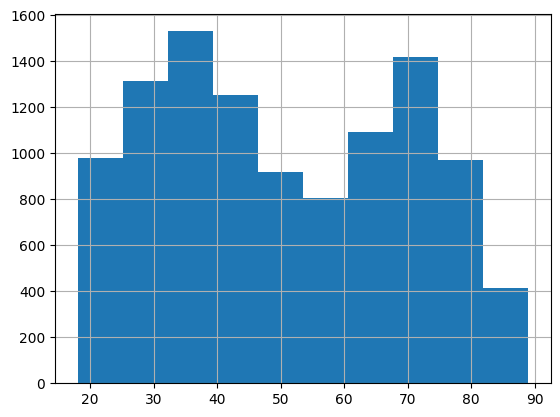

In [ ]:
print(f'Age varies from {df.age.min()} to {df.age.max()}\n')
_=df.age.hist()

In [ ]:
# function used to retun the label from an image
def label_func(file):
    # takes the file's base name w/o the extension
    basename = int(os.path.basename(str(file)).split('.')[0])

    # searches for the label
    label = int(df.age[basename])

    return label

<font color='blue'>Como se trata de un problema de regresión, la salida que queremos del modelos es un número real, por ejemplo 35,6 años, no una etiqueta de clase, vamos a usar RegressionBlock en vez de CategoryBlock.

<font color='blue'>Por otro lado, para la elección del batch size, en este ejercicio no se indica cual tenemos que usar. Como sabemos este valor indica el número de imágenes de los datos de entrenamiento que se procesan en la GPU o CPU antes de que los pesos del modelo se actualizen.

<font color='blue'>Por ello, si ponemos un bach size pequeño, como 8, no va a haber problemas de memoria y va a haber más actualizaciones de pesos, pero también puede haber más varianza en las estimaciones del gradiente. Por otro lado, con una batch size más grande el entrenamiento va a ir más rápido, pero puede dar lugar a problemas de memoria. Por ello nos decantamos con batch size = 64, un tamaño intermedio. Aunque posteriormente se puede cambiar si con un tamaño mayor o menor vemos que funciona mejor.

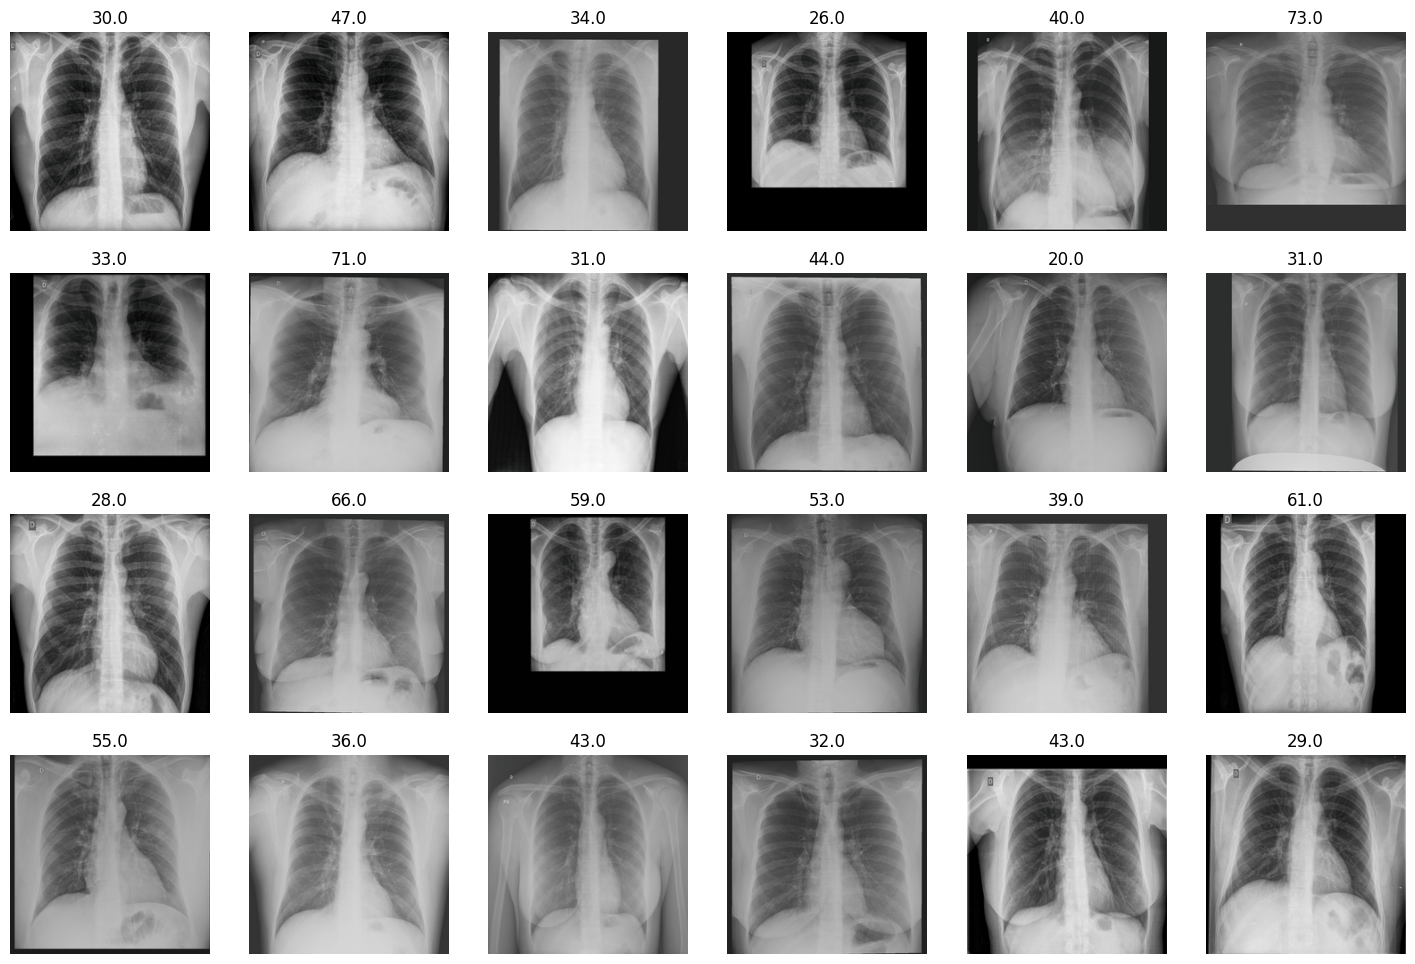

In [ ]:
dtblk = DataBlock(
    blocks=(ImageBlock, RegressionBlock),
    get_items=get_image_files,
    get_y=label_func,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=[Normalize.from_stats(*imagenet_stats)]
)
dls = dtblk.dataloaders(train_path, bs=64)

dls.show_batch(max_n=24)

In [ ]:
print('Numero de ejemplos de entrenamiento (una vez descartados los de validacion):', len(dls.train_ds))
print('Numero de ejemplos de validacion:', len(dls.valid_ds))

Numero de ejemplos de entrenamiento (una vez descartados los de validacion): 5362
Numero de ejemplos de validacion: 1340


## <font color='blue'>3.1 Entrenamos todo ResNet34 _from scratch_, ajustando la cabecera para este problema. (0.75 puntos)

(0.75 puntos) Partimos de ResNet34, adaptamos la cabecera (sustituyendo la cabecera anterior por *una única fully-connected* con el número de neuronas de salida adecuado), y reentrenamos (_from scratch_) la red entera para este nuevo problema durante $15$ épocas. Es decir, partimos de pesos aleatorios para resolver este problema de regresión.

<font color='blue'>Según he visto en internet, la arquitectura ResNet-34 es una red neuronal convolucional de 34 capas de profundidad, diseñada para abordar el problema de la degradación en redes profundas, que ocurre cuando el rendimiento del modelo empeora con el aumento de la profundidad, incluso en datos de entrenamiento.

<font color='blue'>Por otro lado, el problema de la degradación en redes profundas se refiere a la disminución de la precisión observada cuando se añaden más capas a una red neuronal, lo cual es paradójico ya que capas adicionales deberían mejorar la capacidad de representación del modelo.
Este fenómeno está estrechamente relacionado con el problema de la desaparición del gradiente, que ocurre durante el entrenamiento mediante retropropagación, donde los gradientes se vuelven extremadamente pequeños al propagarse desde la capa de salida hacia las capas iniciales.

<font color='blue'>Además, ResNet-34 es un modelo preentrenado en el conjunto de datos ImageNet, que contiene más de un millón de imágenes y 1000 clases. Pero nosotros queremos un solo número, la edad, por ello tenemos que adaptar la cabecera, es decir, quitar la parte final, la que genera la predicción.

<font color='blue'>ResNet-34 tiene una serie de capas convolucionales, tras las cuales llega a un tensor de características de tamaño [batch, 512, 7, 7] donde batch es al tamaño del lote (batch size), que es el número de muestras que se procesan simultáneamente durante el entrenamiento, la dimensión 512 corresponde al número de canales o filtros en la representación de características y las dimensiones 7 y 7 indican el tamaño espacial final. Es decir, que se ha partido de imágenes 224x224 y se han aplicado una serie de operaciones para reducir el tamaño a 7x7 mientras ha aumentado el número de canales para capturar características más abstractas.

<font color='blue'>Posteriormente tiene un AdaptiveAvgPool2d que reduce a [batch, 512, 1, 1]. Flatten, para reformar tensores de entrada en una sola dimensión y Linear($512*1*1$, 1000) = Linear(512, 1000) para clasificar en 1000 clases.

<font color='blue'>Ahora tenemos que aprovechar las capas convolucionales quen han aprendido a ver bordes, texturas, formas... pero modificando la capa final. Quitamos AdaptiveAvgPool2d y Linear(512, 1000) y pasamos de [batch, 512, 7, 7] a un vector de tamaño $512*7*7 = 25088$ mediante Linear.

<font color='blue'>Para ello vamos a usar la función vision_learner para crear el learner (en fastai, cnn_learner es básicamente el nombre antiguo y está marcado como deprecated, así que conviene usar directamente vision_learner). Está pensado para construir un learner a partir de un objeto data loader (dls) y una arquitectura de modelo específica (arch). Algunos de los argumentos clave que acepta incluyen:

- <font color='blue'>dls: el data loader que proporciona los datos de entrenamiento y validación.

- <font color='blue'>arch: la arquitectura del modelo, como resnet18, resnet34 o resnet50.

- <font color='blue'>normalize: si es True, puede añadir automáticamente la normalización adecuada cuando se hace transfer learning con pesos preentrenados.

- <font color='blue'>n_out: número de salidas (en regresión de edad normalmente será 1, es decir, un único valor).

- <font color='blue'>pretrained: si usar o no pesos preentrenados (por ejemplo, de ImageNet).

- <font color='blue'>weights: permite elegir qué pesos preentrenados usar (si aplica).

- <font color='blue'>metrics: métricas opcionales para evaluar el desempeño.

- <font color='blue'>loss_func: función de pérdida personalizada.

- <font color='blue'>opt_func: función de optimización.

- <font color='blue'>lr: tasa de aprendizaje.

- <font color='blue'>wd: weight decay.

- <font color='blue'>cbs: callbacks a usar durante el entrenamiento.

<font color='blue'>La función vision_learner puede personalizarse especificando parámetros como:

- <font color='blue'>cut: define dónde se corta el modelo para separar el body del head.

- <font color='blue'>custom_head: permite definir una cabeza personalizada en lugar de la predeterminada.

<font color='blue'>Luego entrenamos from scratch, que quiere decir partir de pesos aleatorios, no de los preentrenados de ImageNet, por ello tenemos que usar pretrained=False (y típicamente weights=None), y entrenar todos los pesos (cuerpo + cabecera) desde cero sobre el problema de las radiografías.

<font color='blue'>Como función de pérdida vamos a usar la predterminada para problemas de regresión en fastai,  que es el Error Cuadrático Medio (MSE), implementado como MSELossFlat, que aplana (flatten) los tensores de entrada y de destino antes de calcular la pérdida. Además como nos dice el enunciado, vamos a usar las siguiente métricas: 𝑀𝑆𝐸 , 𝑀𝐴𝐸 y 𝑅2 y el optimizador por defecto de fastai que es Adam.

<font color='blue'>MSE(mean squared error) calcula el promedio de las diferencias al cuadrado entre los valores predichos y los valores reales. El MSE se utiliza comúnmente en tareas de regresión porque penaliza los errores grandes de manera más intensa debido al cuadrado de las diferencias, lo que lo hace sensible a valores atípicos (outliers). Por ejemplo, en una tarea de predicción de precios de viviendas, una predicción de $100,000$ frente a un valor real de $101,000$ produce un error cuadrático de $1,000,000$.

<font color='blue'>MAE(mean absolute error) calcula el promedio de las diferencias absolutas entre los valores predichos y los valores reales. También se conoce como norma L1. Puntajes de MAE más bajos indican un mejor ajuste del modelo a los datos, y diferencias significativas entre el MAE del conjunto de entrenamiento y el del conjunto de prueba pueden sugerir sobreajuste (overfitting).

<font color='blue'>El coeficiente de determinación, denotado R², es una medida estadística que representa la proporción de la varianza en la variable dependiente que puede ser explicada por la(s) variable(s) independiente(s). Esta métrica se utiliza para evaluar el rendimiento de modelos de regresión, indicando qué tan bien se ajustan las predicciones del modelo a los datos reales.



In [ ]:
# A CUBRIR POR EL ALUMNADO
NF = 512 * 7 * 7

my_head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(NF, 1)
)

learn1 = vision_learner(
    dls,
    resnet34,
    pretrained=False,
    loss_func=MSELossFlat(),
    metrics=[mae, mse, R2Score()],
    opt_func=Adam,
    cut=-2,
    custom_head=my_head
)

learn1.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

SuggestedLRs(valley=0.001737800776027143)

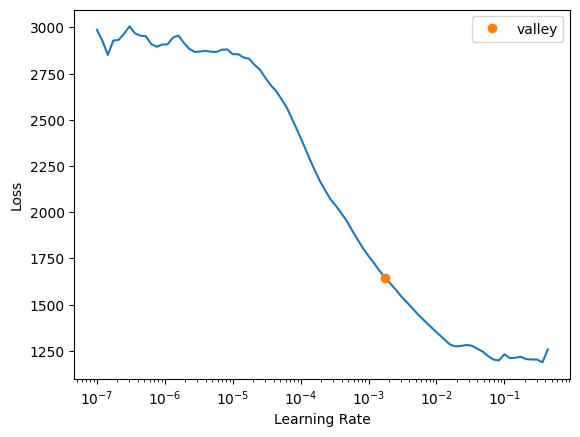

In [ ]:
# A CUBRIR POR EL ALUMNADO
learn1.lr_find()

<font color='blue'>Escogemos como learning rate cuando la pérdida empieza a bajar rápido, y antes de que se dispare hacia arriba.

In [ ]:
learn1.fit(15, 0.001)

epoch,train_loss,valid_loss,mae,mse,r2_score,time
0,325.854706,235.294327,12.549443,235.294327,0.323052,00:44
1,221.361862,184.677933,10.838750,184.677933,0.468677,00:49
2,167.555664,187.937592,10.777005,187.937592,0.459299,00:46
3,137.834442,219.606857,11.144809,219.606857,0.368186,00:50
4,125.590775,113.048889,8.387762,113.048889,0.674756,00:48
5,116.461227,198.818237,10.757894,198.818237,0.427995,00:51
6,102.289757,153.795517,9.540453,153.795517,0.557526,00:46
7,95.839157,112.193420,8.238602,112.193420,0.677217,00:47
8,87.177620,137.189072,9.299643,137.189072,0.605304,00:46
9,86.981819,90.292168,7.540523,90.292168,0.740227,00:47


Train  - loss 38.9968  MAE 4.9494  MSE 38.9968  R2 0.8864
Valid  - loss 91.2636  MAE 7.4915  MSE 91.2636  R2 0.7374
Test   - loss 104.9970  MAE 7.9693  MSE 104.9970  R2 0.7277


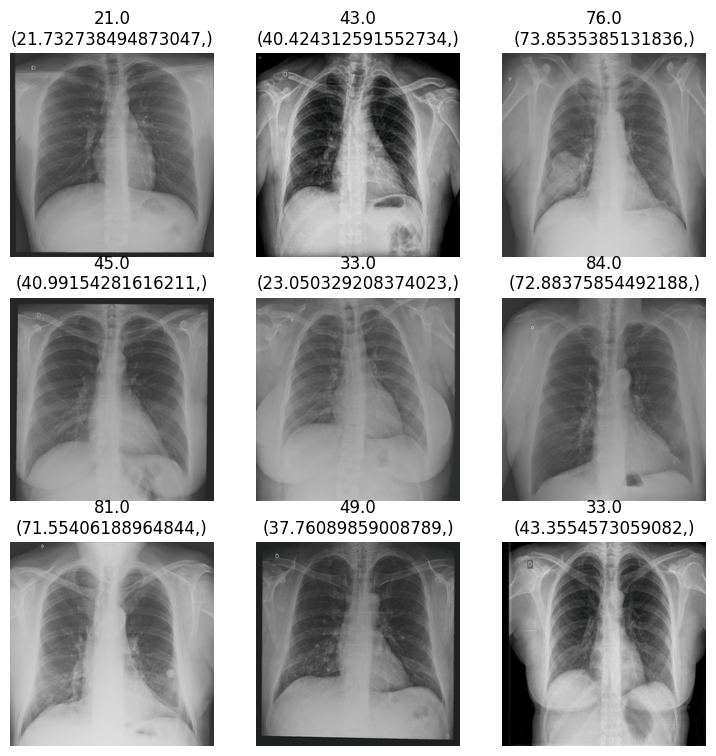

In [ ]:
learn1.show_results()

# Test dataloader (si tu test tiene labels)
test_dl = dls.test_dl(get_image_files(test_path), with_labels=True)

# Train / valid / test
loss_tr, mae_tr, mse_tr, r2_tr = learn1.validate(dl=dls.train)
loss_va, mae_va, mse_va, r2_va = learn1.validate(dl=dls.valid)
loss_te, mae_te, mse_te, r2_te = learn1.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  MAE {mae_tr:.4f}  MSE {mse_tr:.4f}  R2 {r2_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  MAE {mae_va:.4f}  MSE {mse_va:.4f}  R2 {r2_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  MAE {mae_te:.4f}  MSE {mse_te:.4f}  R2 {r2_te:.4f}")

<font color='blue'>**Evaluación del rendimiento**

<font color='blue'>Viendo los resultados en entrenamiento, vemos que el modelo interpreta bien los datos, el valor de MAE nos indica que de media el modelo se equivoca unos 5 años. Con MSE vemos que hay ciertos errores que no son pequeños, ya que está métrica penaliza bastante los errores cuanto más grandes son y con R2 vemos que el modelo explica casi el $89%$ de la variabilidad de la edad, luego está aprendiendo patrones útiles.

<font color='blue'>En cambio en validación y en test vemos que los resultados empeoran notablemente, aunque ligeramente menos en validación que en test, lo que nos lleva a pensar que hay un claro sobreajuste, ya que le cuesta más genelizar a datos nuevos. Esto es coherente con el hecho de estar entrenando desde pesos aleatorios sin aprovechar pesos preentrenados.

<font color='blue'>A pesar de ello, podemos decir haciendo uso del $R^2 > 0.7$ en test, que el modelo aprende una representación útil de la edad a partir de las radiografías

## 3.2. ResNet34 se usa como extractor de características: Entrenamos solo la cabecera incorporada. (1.25 puntos)



(1.25 puntos) Partimos de ResNet34, adaptamos la cabecera (empleando la misma del apartado anterior), y entrenamos solo la cabecera incorporada. Es decir, ResNet34 se usa como un mero extractor de características (preentrenado en ImageNet), y los pesos que se entrenan  durante $15$ épocas son los de la nueva capa incorporada (manteniendo fijos/congelados todos los demás). Como parte de este apartado se deben responder las dos siguientes preguntas:
  
      -> (0.25 puntos) Si no se especifica ninguna `custom_head`, ¿qué incorpora fastai por defecto?
      -> (0.25 puntos) Estamos intentando resolver un problema de regresión por medio de la reutilización de un modelo pre-entrenado en un problema de clasificación (ImageNet). ¿Tiene sentido hacerlo? ¿Por qué nos sirven pesos entrenados en clasificación para un problema de regresión? ¿No son, acaso, problemáticas muy diferentes?

<font color='blue'>Nos piden que los todos los pesos menos los de la capa incorporada estén congelados, vamos a usar el método learn.freeze(), que congela todos los grupos de capas de un modelo excepto el último.
Esto permite que el modelo conserve las características preentrenadas aprendidas de grandes conjuntos de datos, mientras que solo se entrenan las nuevas capas de para la tarea específica. Es decir, durante las 15 épocas solo vamos a entrenar la una única fully-connected layer de 25088 parámetros(o 25.089 con el bias).

<font color='blue'>Un detalle importante es que freeze no congela las capas de BatchNorm2d, de hecho en el summary se puede ver que están a True en la columna *Trainable*, por ello estos parámetros se suman a los 25.089 que teníamos dando un total de 42.113, esto lo hace porque entrenando también estos parámetros se suele obtener mejores resultados.

<font color='blue'>El método funciona estableciendo requires_grad=False para todos los pesos de los grupos de capas congelados, evitando que sus gradientes se calculen y, por lo tanto, que se actualicen durante la retropropagación.

In [ ]:
# A CUBRIR POR EL ALUMNADO
my_head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(NF, 1)
)

learn2 = vision_learner(
    dls,
    resnet34,
    pretrained=True,
    loss_func=MSELossFlat(),
    metrics=[mae, mse, R2Score()],
    opt_func=Adam,
    cut=-2,
    custom_head=my_head
)

learn2.freeze()

learn2.summary()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:04<00:00, 20.6MB/s]


Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

SuggestedLRs(valley=0.002511886414140463)

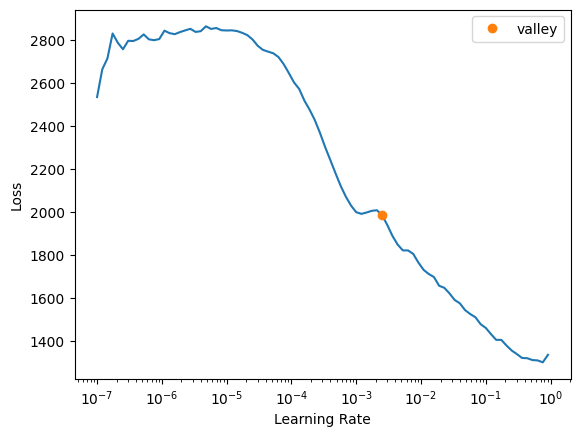

In [ ]:
learn2.lr_find()

<font color='blue'>Escogemos como learning rate cuando la pérdida empieza a bajar rápido, y antes de que se dispare hacia arriba.

In [ ]:
learn2.fit(15, 0.002)

epoch,train_loss,valid_loss,mae,mse,r2_score,time
0,198.694183,95.472221,7.722209,95.472221,0.725324,00:45
1,99.624329,80.912254,7.091135,80.912254,0.767213,00:44
2,66.811394,109.842476,8.360980,109.842476,0.683980,00:54
3,62.141319,113.869019,8.547396,113.869019,0.672396,00:59
4,50.166237,77.098305,6.918297,77.098305,0.778186,00:52
5,42.809166,83.378830,7.151756,83.378830,0.760117,00:44
6,43.173855,76.767143,6.883084,76.767143,0.779139,00:53
7,39.617870,98.719406,7.836465,98.719406,0.715982,00:46
8,34.358810,74.774437,6.723964,74.774437,0.784872,00:54
9,42.530590,79.296989,7.029588,79.296989,0.771861,00:55


Train  - loss 17.3349  MAE 3.3448  MSE 17.3349  R2 0.9495
Valid  - loss 79.0628  MAE 7.0394  MSE 79.0628  R2 0.7725
Test   - loss 70.3435  MAE 6.6329  MSE 70.3435  R2 0.8176


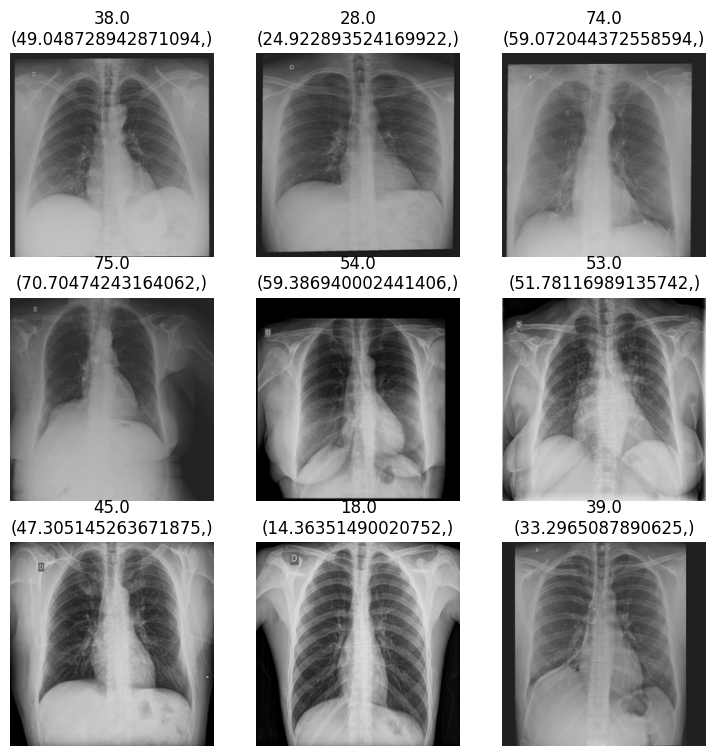

In [ ]:
learn2.show_results()

# Test dataloader (si tu test tiene labels)
test_dl = dls.test_dl(get_image_files(test_path), with_labels=True)

# Train / valid / test
loss_tr, mae_tr, mse_tr, r2_tr = learn2.validate(dl=dls.train)
loss_va, mae_va, mse_va, r2_va = learn2.validate(dl=dls.valid)
loss_te, mae_te, mse_te, r2_te = learn2.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  MAE {mae_tr:.4f}  MSE {mse_tr:.4f}  R2 {r2_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  MAE {mae_va:.4f}  MSE {mse_va:.4f}  R2 {r2_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  MAE {mae_te:.4f}  MSE {mse_te:.4f}  R2 {r2_te:.4f}")

<font color='blue'>**Evaluación del rendimiento**

<font color='blue'>En este apartado hemos usado la red entrenada en ImageNet como extractor de características y hemos entrenado solo la cabecera. Podemos ver que en entrenamiento este modelo ha rducido el error y ha aumentado la explicabilidad(R2 mayor) frente al modelo 1, por lo que es capaz de exploar muy bien las características aprendidas en ImageNet.

<font color='blue'>En cambio en validación y en test vemos que los resultados empeoran notablemente, aunque ligeramente menos en validación que en test, lo que nos lleva a pensar que hay un claro sobreajuste, ya que le cuesta más genelizar a datos nuevos. Sin embargo esta diferencia ahora es algo menor por lo que podemos decir que ha mejorado también.

<font color='blue'>Además podemos decir haciendo uso del $R^2 > 0.8$ en test, que el modelo aprende una representación aun más útil de la edad a partir de las radiografías

###Si no se especifica ninguna `custom_head`, ¿qué incorpora fastai por defecto?

<font color='blue'>En la biblioteca fastai, custom_head permite reemplazar la cabecera predeterminada de una red neuronal convolucional preentrenada (normalmente una capa de adaptive pooling seguida de una capa completamente conectada) con un módulo personalizado adaptado a tareas específicas.

<font color='blue'>El parámetro custom_head se puede pasar a learners como ConvLearner.pretrained o unet_learner, lo que permite tener control total sobre las capas finales del modelo.

<font color='blue'>Si no indicas una cabecera específica, fastai usa una por defecto, que consiste en una concatenación de
- <font color='blue'>AdaptiveAvgPool2d + AdaptiveMaxPool2d
- Flatten
- BatchNorm
- Dropout
- Linear + ReLU
- BatchNorm
- Dropout
- Linear final (acaba en el número de clases)

### Estamos intentando resolver un problema de regresión por medio de la reutilización de un modelo pre-entrenado en un problema de clasificación (ImageNet). ¿Tiene sentido hacerlo? ¿Por qué nos sirven pesos entrenados en clasificación para un problema de regresión? ¿No son, acaso, problemáticas muy diferentes?

<font color='blue'>Sí tiene sentido, ya que las capas convolucionales iniciales de ResNet34 aprender características generales, como bordes texturas, formas regiones... que son útiles tanto para clasificación como regresión.

<font color='blue'>En cambio lo que si hay que modificar es la capa de salida como hemos hecho, además de la función de pérdida.

<font color='blue'>Para un problema de clasificación en la salida tendríamos n clases de neuronas y como función de pérdida usaríamos en general CrossEntropyLoss mientras que para un problema de regresión la salida es una única neurona y en general usaríamos MSELoss.

## 3.3. Hacemos un ajuste fino (fine-tuning) de toda la red partiendo de los pesos de ImageNet. (1 punto)

<font color='blue'>Ahora nos piden en primer lugar entrenar la red del apartado anterior pero solo 5 épocas, es decir, se van a entrenar los 25.088 parámetros de la cabecera más los de las capas de BatchNormalization2D, 42.113 en total, la diferencia viene en el fine tuning posterior entrenando el modelo en su totalidad, por lo que se va a ser uso de todos los parámetros de ResNet34, y al ya estar preentrenada y haber entrenado la cabecera durante 5 épocas, el learning rate que vamos a usar ahora será menor.

In [ ]:
# A CUBRIR POR EL ALUMNADO
my_head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(NF, 1)
)

learn3 = vision_learner(
    dls,
    resnet34,
    pretrained=True,
    loss_func=MSELossFlat(),
    metrics=[mae, mse, R2Score()],
    opt_func=Adam,
    cut=-2,
    custom_head=my_head
)

# Fase 1: solo cabecera (5 épocas)
learn3.freeze()

learn3.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

In [ ]:
learn3.fit(5, 0.002)

epoch,train_loss,valid_loss,mae,mse,r2_score,time
0,159.170944,106.022606,8.162641,106.022606,0.694970,00:43
1,89.962074,86.658707,7.343361,86.658707,0.750681,00:43
2,68.983658,78.638451,7.009301,78.638451,0.773755,00:50
3,56.830860,77.254395,6.974568,77.254395,0.777737,00:49
4,46.849396,79.530403,6.995677,79.530403,0.771189,00:46


In [ ]:
# Fase 2: todo (10 épocas)
learn3.unfreeze()

learn3.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

SuggestedLRs(valley=9.999999747378752e-06)

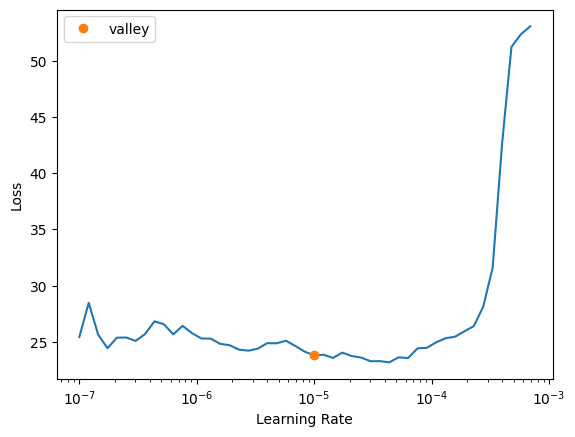

In [ ]:
learn3.lr_find()

<font color='blue'>Escogemos como learning rate cuando la pérdida empieza a bajar rápido, y antes de que se dispare hacia arriba.

In [ ]:
learn3.fit(10, 0.00001)

epoch,train_loss,valid_loss,mae,mse,r2_score,time
0,27.748466,73.652275,6.725629,73.652275,0.788101,00:45
1,14.546954,72.067909,6.637359,72.067909,0.792659,00:55
2,9.483683,72.816475,6.734913,72.816475,0.790505,00:47
3,8.160875,70.534630,6.587310,70.534630,0.797070,00:55
4,6.911507,71.236671,6.630020,71.236671,0.795050,00:59
5,6.614377,70.099442,6.567529,70.099442,0.798322,00:48
6,7.237468,72.174141,6.674139,72.174141,0.792353,00:46
7,7.990823,68.053024,6.445384,68.053024,0.804210,00:45
8,6.554339,67.963379,6.452331,67.963379,0.804468,00:46
9,5.524007,66.916252,6.423929,66.916252,0.807480,00:47


Train  - loss 3.0135  MAE 1.3344  MSE 3.0135  R2 0.9912
Valid  - loss 66.9163  MAE 6.4239  MSE 66.9163  R2 0.8075
Test   - loss 55.1489  MAE 5.8631  MSE 55.1489  R2 0.8570


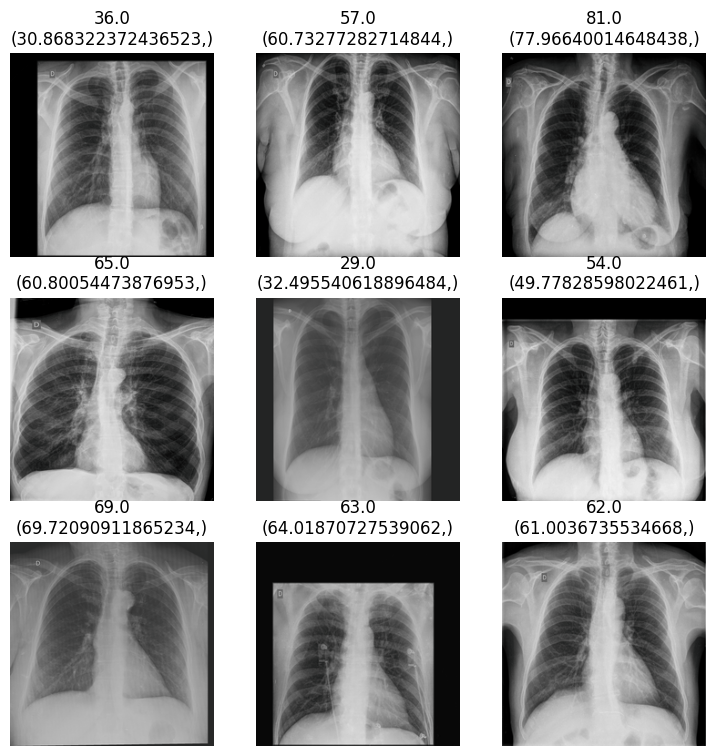

In [ ]:
learn3.show_results()

# Test dataloader (si tu test tiene labels)
test_dl = dls.test_dl(get_image_files(test_path), with_labels=True)

# Train / valid / test
loss_tr, mae_tr, mse_tr, r2_tr = learn3.validate(dl=dls.train)
loss_va, mae_va, mse_va, r2_va = learn3.validate(dl=dls.valid)
loss_te, mae_te, mse_te, r2_te = learn3.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  MAE {mae_tr:.4f}  MSE {mse_tr:.4f}  R2 {r2_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  MAE {mae_va:.4f}  MSE {mse_va:.4f}  R2 {r2_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  MAE {mae_te:.4f}  MSE {mse_te:.4f}  R2 {r2_te:.4f}")

<font color='blue'>**Evaluación del rendimiento**

<font color='blue'>En este apartado hemos partido de la ResNet34 entrenada en ImageNet, hemos ustituido la cabecera por Flatten + Linear(NF --> 1) y hemos entrenado en 2 fases, hemos entrenado 5 épocas solo la cabecera y posteriormente 10 épocas con la red completa(fine-tuning), ahora con un learning rate más bajo.

<font color='blue'>Lás métricas en entrenamiento son casi perfectas, casi no hay error y explica un $99%$ de los datos.

<font color='blue'>En cambio en validación y en test vemos que los resultados empeoran, lo que nos lleva a pensar que sigue habiendo algo de sobreajuste, aunque se ha reducido. En test, es donde hay más mejora.

<font color='blue'>A pesar de ello, podemos decir haciendo uso del $R^2 > 0.85$ en test, que el modelo tiene el mejor de los rendimiento.

### ¿Qué conclusiones se pueden extraer en base a toda la experimentación anterior? En caso de que nos enfrentemos a un nuevo problema, ¿qué opción, u opciones, de entre las anteriores, parece a priori la más razonable? ¿Por qué?

<font color='blue'>A partir de la experimentación realizada se observa, en primer lugar, que entrenar ResNet34 desde cero (from scratch) para este problema de regresión no es la opción más eficiente. Aunque el modelo consigue aprender patrones útiles (MAE de entrenamiento alrededor de 5 años y R2 cercano a 0.89), el rendimiento en validación y test es claramente peor (MAE cercano a 8 años y R2 alrededor de 0.73), lo que indica un sobreajuste importante y una capacidad de generalización limitada.

<font color='blue'>Cuando se utiliza ResNet34 preentrenada en ImageNet como extractor de características y se entrena únicamente la nueva cabecera de regresión, el rendimiento mejora de forma clara respecto al modelo entrenado desde cero. El error medio en validación y test disminuye (MAE en torno a 6.6-7 años) y el R2 aumenta (en torno a 0.8), lo que implica que los pesos preentrenados extraen características generales útiles incluso aunque el problema original fuese de clasificación y el actual sea de regresión. Además, el modelo es más estable y presenta menos sobreajuste que el modelo from scratch.

<font color='blue'>El mejor comportamiento se obtiene en el tercer enfoque, en el que se parte de ResNet34 preentrenada, se entrena primero solo la cabecera durante unas pocas épocas y después se realiza un ajuste fino (fine-tuning) de toda la red con una tasa de aprendizaje menor. En este caso, el MAE en test baja por debajo de 6 años y el R2 se sitúa alrededor de 0.86, superando claramente a las dos configuraciones anteriores. El modelo sigue ajustando muy bien el conjunto de entrenamiento, pero al mismo tiempo mejora la capacidad de generalización en validación y test.

<font color='blue'>En base a toda esta experimentación, la conclusión principal es que aprovechar modelos preentrenados y realizar un proceso de fine-tuning por fases (primero solo la cabecera y luego toda la red) es, en este contexto, la estrategia más razonable y efectiva. Para un nuevo problema similar, con un conjunto de datos de tamaño moderado, la opción más recomendable a priori sería comenzar con una red preentrenada, entrenar únicamente la cabecera y, si se busca el mejor rendimiento posible, continuar después con un ajuste fino de toda la red. Entrenar desde cero solo tendría sentido en escenarios con muchos más datos o cuando el preentrenamiento no aportara información útil.

##3.4. Hacemos un ajuste fino (fine-tuning) de toda la red partiendo de los pesos de ImageNet, pero enfocando el problema como uno de clasificación. (1 punto)

<font color='blue'>En este último apartado debemos seguir la misma metodología que en anterior, en el sentido de primero entrenar la cabecera durante 5 épocas y luego hacer fine tuning de toda la red durante 10 época, por lo que en primer lugar tendremos los 25088 parámetros de antes, 25089 contando el bias, pero ahora la salida no es una neurona, sino una por cada una de las clases, que son las 72 edades que puede haber de 18 a 89, por lo que el número de parámetros debido a la cabecera es $25.089 * 72 = 1806408$ a los que hay que sumarle los de las capas de BatchNormalization dando un total de $1.823.432$.

<font color='blue'>Cuando entrenamos posteriormente todo el modelo durante 10 épocas se van a entrenar todos los parámetros de la red.

In [ ]:
# A CUBRIR POR EL ALUMNADO
# DataBlock para clasificación de edad
dtblk_clas = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=label_func,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=[Normalize.from_stats(*imagenet_stats)]
)

dls_clas = dtblk_clas.dataloaders(train_path, bs=64)
n_classes = dls_clas.c

my_head_clas = nn.Sequential(
    nn.Flatten(),
    nn.Linear(NF, n_classes)
)

learn4 = vision_learner(
    dls_clas,
    resnet34,
    pretrained=True,
    loss_func=CrossEntropyLossFlat(),
    metrics=[accuracy, F1Score(average='macro')],
    opt_func=Adam,
    cut=-2,
    custom_head=my_head_clas

)

# Fase 1: solo cabecera (5 épocas)
learn4.freeze()

learn4.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

SuggestedLRs(valley=2.511886486900039e-05)

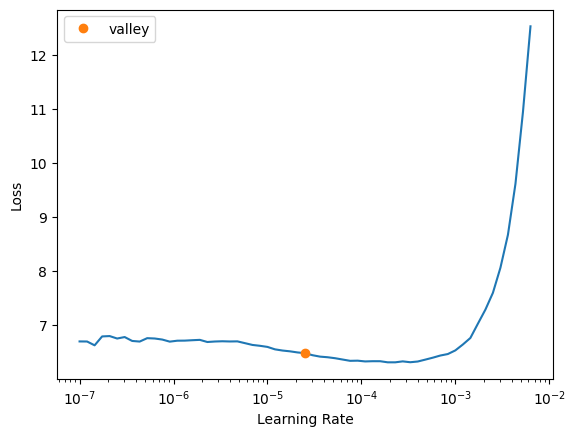

In [ ]:
learn4.lr_find()

In [ ]:
learn4.fit(5, 0.00003)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,5.452188,5.329847,0.020149,0.013692,01:38
1,4.641554,5.163002,0.025373,0.019141,00:43
2,4.008228,5.115881,0.023134,0.020545,00:43
3,3.449630,5.043375,0.027612,0.021185,00:44
4,2.990170,5.008241,0.026119,0.020795,00:43


In [ ]:
# Fase 2: todo (10 épocas)
learn4.unfreeze()

learn4.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 112 x 112 
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 56 x 56   
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                      

SuggestedLRs(valley=5.754399353463668e-06)

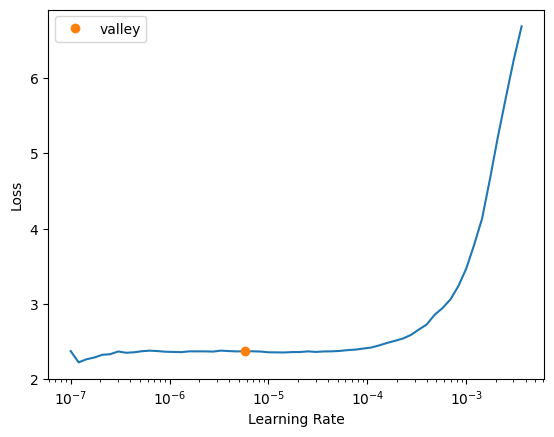

In [ ]:
learn4.lr_find()

In [ ]:
learn4.fit(10, 0.000006)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.434991,4.925149,0.027612,0.025209,00:50
1,1.940203,4.955134,0.030597,0.026157,00:47
2,1.522569,4.955817,0.032090,0.027290,00:48
3,1.144202,4.976448,0.025373,0.022301,00:50
4,0.848461,5.002637,0.029851,0.026452,00:49
5,0.608278,5.012066,0.033582,0.028750,00:52
6,0.418051,5.036015,0.036567,0.029648,00:52
7,0.296912,5.044525,0.035821,0.029529,00:52
8,0.205521,5.060041,0.029851,0.024043,00:51
9,0.146998,5.089415,0.031343,0.027789,00:54


Train  - loss 0.0570  acc 1.0000  F1 1.0000
Valid  - loss 5.0894  acc 0.0313  F1 0.0278
Test   - loss 4.9754  acc 0.0393  F1 0.0284


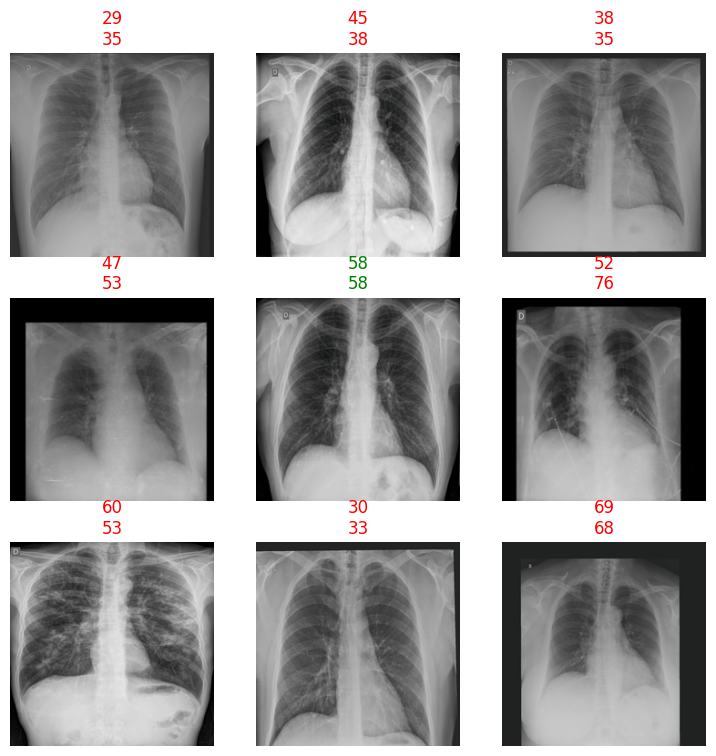

In [ ]:
learn4.show_results()

# Test dataloader para CLASIFICACIÓN
test_dl = dls_clas.test_dl(get_image_files(test_path), with_labels=True)

# Train / valid / test (CLASIFICACIÓN)
loss_tr, acc_tr, f1_tr = learn4.validate(dl=dls_clas.train)
loss_va, acc_va, f1_va = learn4.validate(dl=dls_clas.valid)
loss_te, acc_te, f1_te = learn4.validate(dl=test_dl)

print(f"Train  - loss {loss_tr:.4f}  acc {acc_tr:.4f}  F1 {f1_tr:.4f}")
print(f"Valid  - loss {loss_va:.4f}  acc {acc_va:.4f}  F1 {f1_va:.4f}")
print(f"Test   - loss {loss_te:.4f}  acc {acc_te:.4f}  F1 {f1_te:.4f}")

<font color='blue'>**¿Qué conclusiones extrae de este experimento? ¿Qué aproximación, a priori, parece más adecuada: regresión o clasificación?**

<font color='blue'>En este experimento se ha planteado la predicción de la edad como un problema de clasificación, asignando una clase a cada edad entera en el rango [18, 89]. El modelo obtiene un rendimiento perfecto en entrenamiento (loss muy baja y accuracy y F1 iguales a 1), lo que indica que memoriza prácticamente todo el conjunto de entrenamiento. Sin embargo, en validación y test la accuracy se sitúa en torno al 3–4 % y el F1 es también muy bajo, con una función de pérdida relativamente alta. Esto muestra un claro sobreajuste: el modelo aprende a “recordar” los ejemplos de entrenamiento, pero apenas generaliza a datos nuevos, comportándose casi como si estuviera eligiendo la clase al azar.

<font color='blue'>Hay varias razones que explican este mal comportamiento al usar clasificación. Por un lado, la edad es una variable continua y ordinal, pero al tratarla como clasificación con una clase por año se está forzando a que el modelo vea esas edades como categorías completamente independientes. De este modo, predecir 40 cuando la edad real es 41 se penaliza exactamente igual que predecir 80, aunque intuitivamente 40 está mucho más cerca. Además, el número de clases es alto (72 edades posibles) y el número de ejemplos por edad puede ser relativamente pequeño y desbalanceado.

<font color='blue'>Si comparamos estos resultados con los obtenidos en los modelos de regresión, la diferencia es clara. En regresión se alcanzan errores medios en test en torno a 6 años y valores de R2 cercanos a 0.86, lo que implica que el modelo explica una parte muy significativa de la variabilidad de la edad. En cambio, el modelo de clasificación apenas acierta la edad exacta en un pequeño porcentaje de casos y no ofrece una aproximación útil en términos prácticos. Dado que lo que interesa en este contexto es aproximarse razonablemente a la edad real y no tanto acertar exactamente el año, la formulación como regresión es mucho más adecuada.

<font color='blue'>Por todo ello, la conclusión es que, para este problema de predicción de edad a partir de radiografías, la aproximación de regresión resulta a priori claramente preferible a la de clasificación con una clase por año. En la práctica, si nos enfrentamos a un problema similar, lo más razonable sería modelarlo como regresión y no como clasificación multiclase con tantas clases como valores posibles de la variable objetivo.